In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Import dataset
from sklearn.datasets import load_breast_cancer

# For precision, recall, etc.
from sklearn.metrics import classification_report

In [2]:
X, y = load_breast_cancer(return_X_y=True)

In [3]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()

# Scale data
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.model_selection import train_test_split

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=10)

In [5]:
from sklearn.linear_model import LogisticRegression

In [6]:
lm_full = LogisticRegression()

In [7]:
lm_full.fit(X_train, y_train)

LogisticRegression()

In [8]:
pred_lm_full = lm_full.predict(X_test)

In [9]:
lm_vt = LogisticRegression()

In [10]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.02)

# Transform (i.e.: run selection on) the training data
X_train_vt = selector.fit_transform(X_train)

In [11]:
X_train_vt.shape

(455, 15)

In [12]:
lm_vt.fit(X_train_vt, y_train)

LogisticRegression()

In [13]:
X_test_vt = selector.transform(X_test)

# Generate predictions from var thresh model
pred_lm_vt = lm_vt.predict(X_test_vt)

In [14]:
lm_kbest = LogisticRegression()

In [15]:
from sklearn import feature_selection
from sklearn.feature_selection import f_classif

# Set up selector, choosing score function and number of features to retain
selector_kbest = feature_selection.SelectKBest(score_func=f_classif, k=20)

# Transform (i.e.: run selection on) the training data
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)

In [16]:
X_train_kbest.shape

(455, 20)

In [17]:
lm_kbest.fit(X_train_kbest, y_train)

LogisticRegression()

In [18]:
X_test_kbest = selector_kbest.transform(X_test)

# Generate predictions from var thresh model
pred_lm_kbest = lm_kbest.predict(X_test_kbest)

In [19]:
lm_sfs = LogisticRegression()

In [20]:
from sklearn.metrics import f1_score
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

In [21]:
sfs = sfs(lm_sfs, k_features=25, forward=True, scoring='f1', cv=10)

In [22]:
sfs = sfs.fit(X_train, y_train)

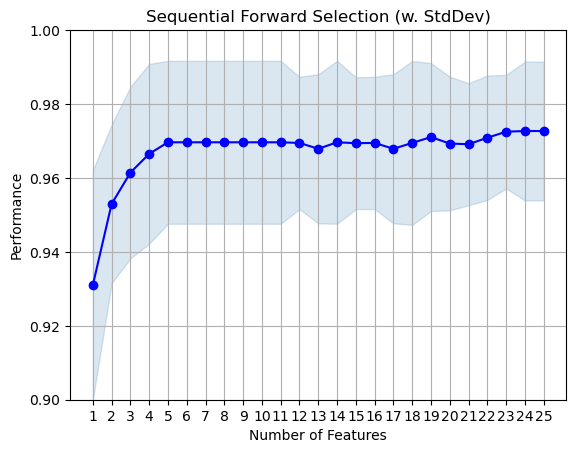

In [23]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.ylim([0.9, 1])
plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

In [24]:
columns = list(sfs.subsets_[21]['feature_idx'])

In [25]:
X_train_sfs = X_train[:, columns]
X_test_sfs = X_test[:, columns]

In [26]:
X_train_sfs.shape

(455, 21)

In [27]:
lm_sfs.fit(X_train_sfs, y_train)

LogisticRegression()

In [28]:
pred_lm_sfs = lm_sfs.predict(X_test_sfs)

In [29]:
print('Full Model')
print(classification_report(y_test, pred_lm_full, target_names=['Malignant', 'Benign']))

print('Var Thresh Model')
print(classification_report(y_test, pred_lm_vt, target_names=['Malignant', 'Benign']))

print('KBest Model')
print(classification_report(y_test, pred_lm_kbest, target_names=['Malignant', 'Benign']))

print('SFS Model')
print(classification_report(y_test, pred_lm_sfs, target_names=['Malignant', 'Benign']))

Full Model
              precision    recall  f1-score   support

   Malignant       1.00      1.00      1.00        39
      Benign       1.00      1.00      1.00        75

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

Var Thresh Model
              precision    recall  f1-score   support

   Malignant       0.97      0.97      0.97        39
      Benign       0.99      0.99      0.99        75

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

KBest Model
              precision    recall  f1-score   support

   Malignant       1.00      1.00      1.00        39
      Benign       1.00      1.00      1.00        75

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00 

In [30]:
print('SFS Model')
print(classification_report(y_test, pred_lm_sfs, target_names=['Malignant', 'Benign']))

SFS Model
              precision    recall  f1-score   support

   Malignant       1.00      1.00      1.00        39
      Benign       1.00      1.00      1.00        75

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



In [31]:
# Small C
model_1 = LogisticRegression(C=0.05, penalty='l1', solver='liblinear', verbose=1)

# Default C
model_2 = LogisticRegression(C=1)

# Large C
model_3 = LogisticRegression(C=10)

In [32]:
model_1.fit(X_train, y_train)
model_2.fit(X_train, y_train)
model_3.fit(X_train, y_train)

[LibLinear]

LogisticRegression(C=10)

In [33]:
model_1.coef_
model_2.coef_
model_3.coef_

array([[-2.47698413, -3.29766838, -2.36009471, -2.45654457, -0.91942132,
         1.36260736, -2.89647159, -3.65734995,  0.06006976,  1.89942543,
        -4.65053952, -0.22714002, -3.26171166, -2.62306583, -0.67412069,
         3.37482478,  0.2937626 , -0.7994922 ,  2.42401466,  1.99139459,
        -4.53183383, -4.8162922 , -3.91003277, -3.51994646, -3.05255678,
        -0.38599861, -3.21201043, -3.83851487, -2.75861462, -0.90627326]])

In [34]:
pred_1 = model_1.predict(X_test)
pred_2 = model_2.predict(X_test)
pred_3 = model_3.predict(X_test)

In [35]:
print('C = 0.05')
print(classification_report(y_test, pred_1, target_names=['Malignant', 'Benign']))

print('C = 1')
print(classification_report(y_test, pred_2, target_names=['Malignant', 'Benign']))

print('C = 10')
print(classification_report(y_test, pred_3, target_names=['Malignant', 'Benign']))

C = 0.05
              precision    recall  f1-score   support

   Malignant       0.96      0.62      0.75        39
      Benign       0.83      0.99      0.90        75

    accuracy                           0.86       114
   macro avg       0.90      0.80      0.83       114
weighted avg       0.88      0.86      0.85       114

C = 1
              precision    recall  f1-score   support

   Malignant       1.00      1.00      1.00        39
      Benign       1.00      1.00      1.00        75

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114

C = 10
              precision    recall  f1-score   support

   Malignant       0.97      0.97      0.97        39
      Benign       0.99      0.99      0.99        75

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       11